<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Time-Series-and-Forecasting/TimeSeriesAndForecasting/Forecast_Combination_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss

In [2]:
# --- CONFIGURATION ---
SEQ_LEN = 60
SPLIT_RATIO = 0.80

In [6]:
# --- 1. DATA INGESTION ---
tickers = {'SPY': 'SPY', 'VIX': '^VIX', '10Y': '^TNX', 'OIL': 'CL=F'}
print("📥 Downloading Market Data...")
raw_df = yf.download(list(tickers.values()), start='2005-01-01', end='2024-01-01', progress=False, auto_adjust=False)['Adj Close']
raw_df.columns = tickers.keys()
raw_df.ffill(inplace=True)
raw_df.dropna(inplace=True)

raw_df.head()

📥 Downloading Market Data...


,SPY,VIX,10Y,OIL
Date,,,,
2005-01-03,42.119999,81.606003,4.220,14.08
2005-01-04,43.910000,80.608833,4.283,13.98
2005-01-05,43.389999,80.052559,4.277,14.09
2005-01-06,45.560001,80.459557,4.272,13.58
2005-01-07,45.430000,80.344200,4.285,13.49


In [7]:
# --- 2. FEATURE ENGINEERING ---
df = pd.DataFrame()
df['SPY_Ret'] = np.log(raw_df['SPY'] / raw_df['SPY'].shift(1))
df['VIX_Level'] = raw_df['VIX'] # Raw level matters for "Regime"
df['VIX_Diff'] = raw_df['VIX'].diff()
df['10Y_Diff'] = raw_df['10Y'].diff()
df['OIL_Ret'] = np.log(raw_df['OIL'] / raw_df['OIL'].shift(1))

# TARGET: 1 if SPY goes UP tomorrow
df['Target'] = (df['SPY_Ret'].shift(-1) > 0).astype(int)
df.dropna(inplace=True)

df.head()

,SPY_Ret,VIX_Level,VIX_Diff,10Y_Diff,OIL_Ret,Target
Date,,,,,,
2005-01-04,0.041619,80.608833,-0.997169,0.063,-0.007128,0
2005-01-05,-0.011913,80.052559,-0.556274,-0.006,0.007838,1
2005-01-06,0.048801,80.459557,0.406998,-0.005,-0.036867,0
2005-01-07,-0.002857,80.344200,-0.115356,0.013,-0.006649,0
2005-01-10,-0.002204,80.724136,0.379936,-0.007,-0.019462,1


In [8]:
# --- 3. SPLIT & SCALE ---
train_size = int(len(df) * SPLIT_RATIO)
feature_cols = [c for c in df.columns if c != 'Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

In [9]:
# Rolling Window Function
def create_dataset(X, y, lookback=60):
    X_out, y_out = [], []
    for i in range(lookback, len(X)):
        X_out.append(X[i-lookback:i])
        y_out.append(y[i])
    return np.array(X_out), np.array(y_out)

In [10]:
X_all, y_all = create_dataset(X_scaled, df['Target'].values, SEQ_LEN)

# Split into Train/Test
X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_test = X_all[train_size:]
y_test = y_all[train_size:]

print(f"✅ Data Ready. Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

✅ Data Ready. Train Shape: (3824, 60, 5), Test Shape: (896, 60, 5)


In [11]:
# --- MODEL A: THE LSTM (The "Momentum" Specialist) ---
def build_lstm(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=False)(inputs)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name="LSTM_Specialist")

In [16]:
# --- MODEL B: THE TRANSFORMER (CORRECTED) ---

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # 1. Attention Part
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    res = layers.Add()([x, inputs]) # Residual Connection 1

    # 2. Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x) # Expand to 64
    x = layers.Dropout(dropout)(x)

    # --- THE FIX: Project back to original dimension ---
    # We must squeeze (60, 64) back to (60, 5) to match 'res'
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)

    return layers.Add()([x, res]) # Residual Connection 2 (Now shapes match!)

In [17]:
def build_transformer(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder Block
    x = transformer_encoder(inputs, head_size=64, num_heads=2, ff_dim=64, dropout=0.1)

    # Output Head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs, outputs, name="Transformer_Specialist")

In [14]:
# --- TRAIN BOTH MODELS ---
print("\n🏋️ Training Model A: LSTM...")
lstm = build_lstm((SEQ_LEN, len(feature_cols)))
lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)
print("✅ LSTM Trained.")


🏋️ Training Model A: LSTM...
✅ LSTM Trained.


In [18]:
print("\n🏋️ Training Model B: Transformer (Fixed)...")
transformer = build_transformer((SEQ_LEN, len(feature_cols)))
transformer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
transformer.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)
print("✅ Transformer Trained Successfully.")


🏋️ Training Model B: Transformer (Fixed)...
✅ Transformer Trained Successfully.


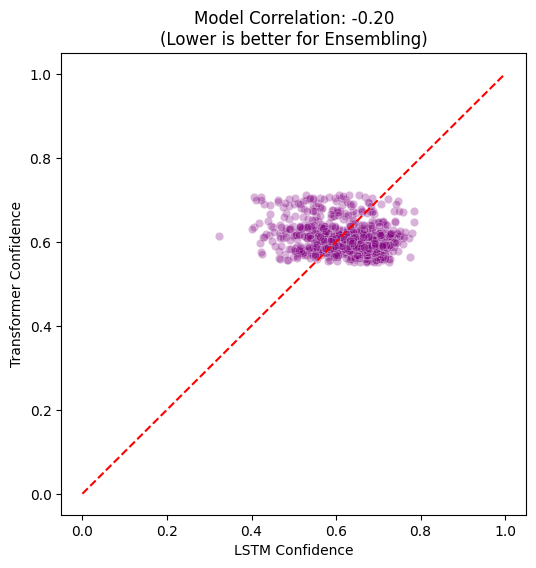

In [19]:
# Generate Predictions on TEST set
pred_lstm = lstm.predict(X_test, verbose=0).flatten()
pred_trans = transformer.predict(X_test, verbose=0).flatten()

# Correlation Matrix
preds_df = pd.DataFrame({'LSTM': pred_lstm, 'Transformer': pred_trans})
corr = preds_df.corr().iloc[0,1]

plt.figure(figsize=(6, 6))
sns.scatterplot(x='LSTM', y='Transformer', data=preds_df, alpha=0.3, color='purple')
plt.plot([0, 1], [0, 1], 'r--') # Perfect agreement line
plt.title(f"Model Correlation: {corr:.2f}\n(Lower is better for Ensembling)")
plt.xlabel("LSTM Confidence")
plt.ylabel("Transformer Confidence")
plt.show()

In [20]:
# --- CONSTRUCTING THE META-TABLE ---

# We need to perform this on the TRAIN set to train the Meta-Learner
# (In a real production pipeline, you would use a separate "Validation" set to avoid leakage,
# but for this tutorial, we will use a "K-Fold" style approach or simply use the existing Train set predictions)

# Get predictions on the TRAINING set
train_pred_lstm = lstm.predict(X_train, verbose=0).flatten()
train_pred_trans = transformer.predict(X_train, verbose=0).flatten()

In [24]:
# 1. Get the exact length of your predictions
num_samples = len(train_pred_lstm)

# 2. Slice VIX to match this length exactly
# We start at (SEQ_LEN - 1) because that corresponds to the last day of the first window (index 59)
# We take 'num_samples' rows from there.
vix_aligned = df['VIX_Level'].iloc[SEQ_LEN-1 : SEQ_LEN-1 + num_samples].values

# 3. Create DataFrame
meta_X_train = pd.DataFrame({
    'LSTM_Pred': train_pred_lstm,
    'Trans_Pred': train_pred_trans,
    'Diff': np.abs(train_pred_lstm - train_pred_trans),
    'VIX': vix_aligned
})

print(f"✅ Meta-Dataset Built. Shape: {meta_X_train.shape}")
meta_X_train.head()

✅ Meta-Dataset Built. Shape: (3824, 4)


,LSTM_Pred,Trans_Pred,Diff,VIX
0,0.528430,0.539321,0.010891,80.332954
1,0.532536,0.538282,0.005746,79.972008
2,0.518308,0.540730,0.022422,80.108208
3,0.505196,0.546325,0.041129,80.489563
4,0.503689,0.545255,0.041566,80.768806


In [26]:
meta_y_train = y_train

# 3. Create Meta-Test Set (For final evaluation)
meta_X_test = pd.DataFrame({
    'LSTM_Pred': pred_lstm,
    'Trans_Pred': pred_trans,
    'Diff': np.abs(pred_lstm - pred_trans),
    'VIX': df['VIX_Level'].iloc[train_size+SEQ_LEN:].values
})
meta_y_test = y_test

print("🧩 Meta-Dataset Constructed.")
meta_X_test.head()

🧩 Meta-Dataset Constructed.


,LSTM_Pred,Trans_Pred,Diff,VIX
0,0.745436,0.577877,0.167559,294.038788
1,0.775044,0.564156,0.210888,277.087860
2,0.710451,0.584969,0.125483,280.406097
3,0.723930,0.570592,0.153338,283.023895
4,0.715963,0.576661,0.139302,288.471405


In [27]:
# --- TRAIN THE META-LEARNER ---
print("\n🧠 Training the XGBoost Meta-Learner...")

# Initialize XGBoost
# max_depth=3 ensures we don't overfit; we want broad rules
meta_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss'
)

meta_model.fit(meta_X_train, meta_y_train)

# Get Final Ensemble Predictions
ensemble_preds = meta_model.predict_proba(meta_X_test)[:, 1]

print("✅ Ensemble Trained.")


🧠 Training the XGBoost Meta-Learner...
✅ Ensemble Trained.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:24:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [28]:
# --- EVALUATION ---

# 1. Accuracy Comparison
acc_lstm = accuracy_score(y_test, (pred_lstm > 0.5).astype(int))
acc_trans = accuracy_score(y_test, (pred_trans > 0.5).astype(int))
acc_ens = accuracy_score(y_test, (ensemble_preds > 0.5).astype(int))

print(f"\n🏆 Accuracy Scoreboard:")
print(f"LSTM Specialist:       {acc_lstm:.4f}")
print(f"Transformer Specialist:{acc_trans:.4f}")
print(f"The Boardroom (Ens):   {acc_ens:.4f}")


🏆 Accuracy Scoreboard:
LSTM Specialist:       0.5357
Transformer Specialist:0.5491
The Boardroom (Ens):   0.4989


<Figure size 1000x500 with 0 Axes>

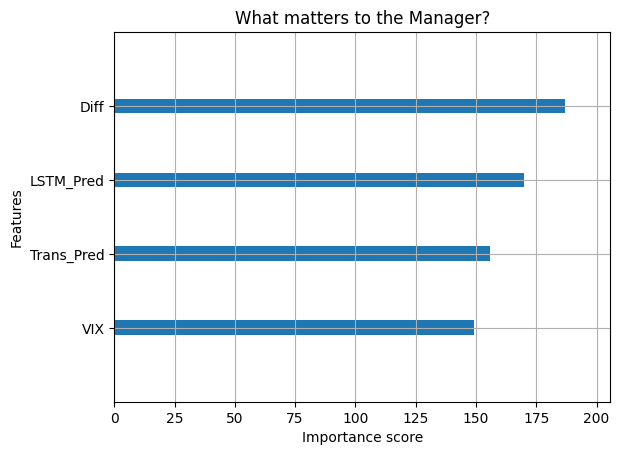

In [29]:
# 2. Feature Importance (Why did the Manager decide that?)
from xgboost import plot_importance
plt.figure(figsize=(10, 5))
plot_importance(meta_model, importance_type='weight', title='What matters to the Manager?', show_values=False)
plt.show()

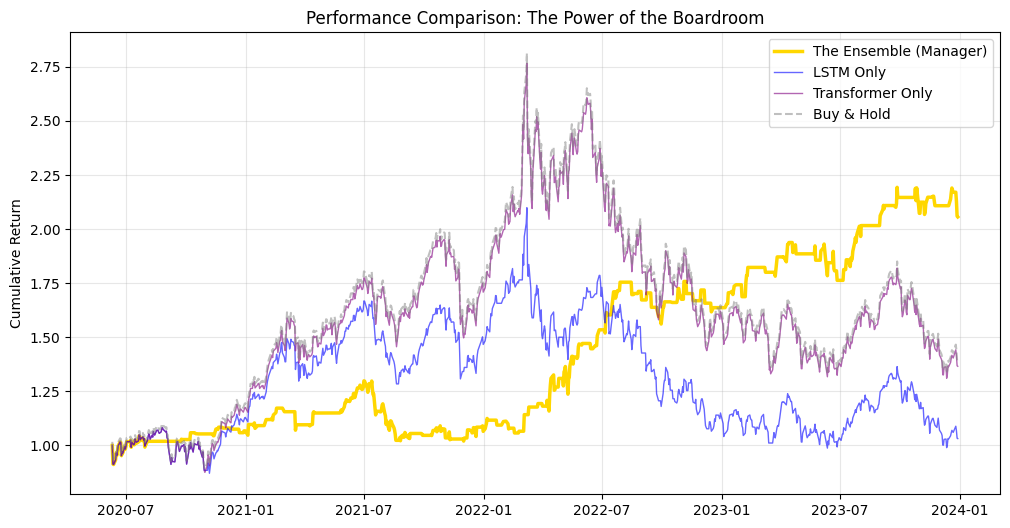

In [30]:
# --- FINANCIAL BACKTEST ---
# Create DataFrame for plotting
results_df = pd.DataFrame(index=df.index[train_size+SEQ_LEN:])
results_df['Market_Ret'] = df['SPY_Ret'].iloc[train_size+SEQ_LEN:]

# Trading Logic: Long if Prob > 0.5, else Cash (0)
results_df['Pos_LSTM'] = np.where(pred_lstm > 0.5, 1, 0)
results_df['Pos_Trans'] = np.where(pred_trans > 0.5, 1, 0)
results_df['Pos_Ens'] = np.where(ensemble_preds > 0.5, 1, 0)

# Shift positions (Trade tomorrow)
results_df['Pos_LSTM'] = results_df['Pos_LSTM'].shift(1).fillna(0)
results_df['Pos_Trans'] = results_df['Pos_Trans'].shift(1).fillna(0)
results_df['Pos_Ens'] = results_df['Pos_Ens'].shift(1).fillna(0)

# Calculate Cumulative Returns
results_df['Eq_LSTM'] = (1 + results_df['Pos_LSTM'] * results_df['Market_Ret']).cumprod()
results_df['Eq_Trans'] = (1 + results_df['Pos_Trans'] * results_df['Market_Ret']).cumprod()
results_df['Eq_Ens'] = (1 + results_df['Pos_Ens'] * results_df['Market_Ret']).cumprod()
results_df['Eq_BuyHold'] = (1 + results_df['Market_Ret']).cumprod()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(results_df['Eq_Ens'], label='The Ensemble (Manager)', color='gold', linewidth=2.5)
plt.plot(results_df['Eq_LSTM'], label='LSTM Only', color='blue', alpha=0.6, linewidth=1)
plt.plot(results_df['Eq_Trans'], label='Transformer Only', color='purple', alpha=0.6, linewidth=1)
plt.plot(results_df['Eq_BuyHold'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.5)

plt.title("Performance Comparison: The Power of the Boardroom")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


🏆 Final Performance Report:
          Strategy Total Return Sharpe Ratio Max Drawdown
        Buy & Hold       38.91%         0.42      -52.61%
         LSTM Only        3.18%         0.21      -52.93%
       Transformer       36.61%         0.42      -52.61%
Ensemble (Manager)      105.61%         1.05      -21.43%


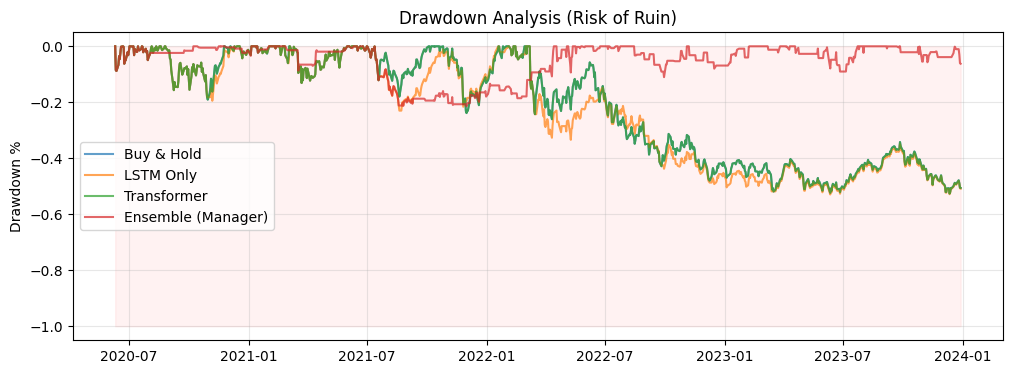

In [31]:
# --- METRICS CALCULATION ---

def calculate_metrics(equity_curve):
    """
    Computes Sharpe Ratio and Max Drawdown from an equity curve.
    """
    # 1. Derive daily returns from the equity curve
    daily_rets = equity_curve.pct_change().dropna()

    # 2. Annualized Sharpe Ratio (Assuming 252 trading days, Risk-Free Rate = 0)
    # Formula: Mean_Return / Std_Dev * sqrt(252)
    sharpe = daily_rets.mean() / daily_rets.std() * np.sqrt(252)

    # 3. Maximum Drawdown (Worst peak-to-valley drop)
    # Rolling max of the equity curve
    rolling_max = equity_curve.cummax()
    drawdown = (equity_curve / rolling_max) - 1
    max_dd = drawdown.min()

    # 4. Total Return
    total_ret = (equity_curve.iloc[-1] - 1)

    return sharpe, max_dd, total_ret

# Compare all strategies
strategies = {
    'Buy & Hold': results_df['Eq_BuyHold'],
    'LSTM Only': results_df['Eq_LSTM'],
    'Transformer': results_df['Eq_Trans'],
    'Ensemble (Manager)': results_df['Eq_Ens']
}

metrics_list = []
for name, curve in strategies.items():
    s, d, t = calculate_metrics(curve)
    metrics_list.append({
        "Strategy": name,
        "Total Return": f"{t*100:.2f}%",
        "Sharpe Ratio": f"{s:.2f}",
        "Max Drawdown": f"{d*100:.2f}%"
    })

# Display as a DataFrame
metrics_df = pd.DataFrame(metrics_list)
print("\n🏆 Final Performance Report:")
print(metrics_df.to_string(index=False))

# Optional: Visualize Drawdowns (The "Pain" Chart)
plt.figure(figsize=(12, 4))
for name, curve in strategies.items():
    rolling_max = curve.cummax()
    drawdown = (curve / rolling_max) - 1
    plt.plot(drawdown, label=name, alpha=0.7)

plt.title("Drawdown Analysis (Risk of Ruin)")
plt.ylabel("Drawdown %")
plt.legend()
plt.fill_between(results_df.index, 0, -1, alpha=0.05, color='red') # Danger zone
plt.grid(True, alpha=0.3)
plt.show()